# Analítica Avanzada de Datos
## Práctica 2. Predicción de Gastos Médicos

# Equipo 9

Integrantes del equipo:
- Antonio Eugenio Daniel
- Domínguez Espinoza Juan Pablo
- Gutierrez Peña Montserrath
- León Villagomez Antonio

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Parte 1

## Carga y exploracion inicial

El dataset que utilizarán es **"US Health Insurance Dataset"**  https://www.kaggle.com/datasets/teertha/ushealthinsurancedataset

In [61]:
data_raw = pd.read_csv('insurance.csv')
data_raw.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [62]:
data_raw.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [63]:
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Para poder realizar un analsis del dataset se busca identidicar el significado de las variables:
- age (edad)
    Representa la edad del cliente, es un dato de tipo entero.
- sex (sexo)
    Representa el sexo del cliente, es un dato de tipo cadena.
- bmi (imc/indice de masa coportal)
    Representa el indice de masa corporal del cliente, es un dato de tipo flotante.
- childen (hijos)
    Representa el numero de hijos del cliente, es un dato de tipo entero.
- smoker (fumador)
    Representa si el cliente es fumador o no, es un dato de tipo cadena(si o no).
- region
    Representa la parte especifica de residencia del cliente en Estados Unidos(norte, sur, este u oeste), es un dato de tipo cadena.
- charges (cargos)
    Representa los cargos medicos facturados del seguro del cliente, es un dato de tipo flotante.


Este dataset es utlizado con el proposito de carculo de costo para seguros, las variables presentan factores de interes para las aseguradoras al momento de determinvar la viabilidad y rentabilidad de un cliente segun las caracteristicas que posee.

El dataset posee 1338 registros, sin ningun valor nulo.

# Limpieza del data set

In [64]:
# Verificar la existencia de valores nulos
data_raw.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Se observa que no hay presencia de valores nulos en las dimensiones del dataset

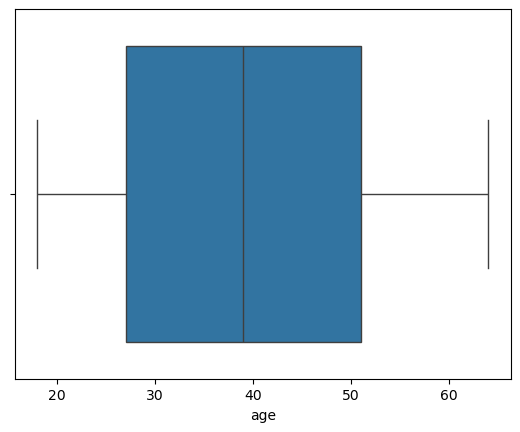

In [65]:
# Presencia de valores atipicos
sns.boxplot(x=data_raw['age'])
plt.show()

No se presentan valores atipicos, los limites son aproximadamente:
limite inferior: 18(aprox).
limite superior: 70(aprox).

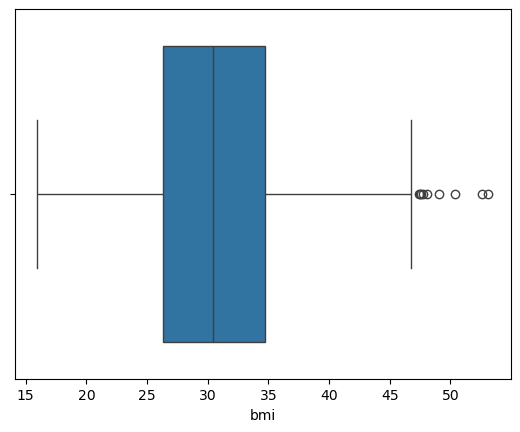

In [66]:
sns.boxplot(x=data_raw['bmi'])
plt.show()

En el indice de masa corporal se observa la presencia de valores atipicos, por lo que se usa el proceso de IQR.

In [67]:
Q1 = data_raw["bmi"].quantile(0.25)
Q3 = data_raw["bmi"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_bmi = data_raw[(data_raw["bmi"] < limite_inferior) | (data_raw["bmi"] > limite_superior)]

In [68]:
outliers_bmi.sort_values(by="bmi", ascending=False)

,age,sex,bmi,children,smoker,region,charges
1317,18,male,53.13,0,no,southeast,1163.46270
1047,22,male,52.58,1,yes,southeast,44501.39820
847,23,male,50.38,1,no,southeast,2438.05520
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
1088,52,male,47.74,1,no,southeast,9748.91060
860,37,female,47.60,2,yes,southwest,46113.51100
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801


Los valores atipicos encontrados no representan errores en la captura de los datos, en su lugar son casos extremos del indice de masa coorporal de los clientes, por lo que en este caso se decide preservarlos.

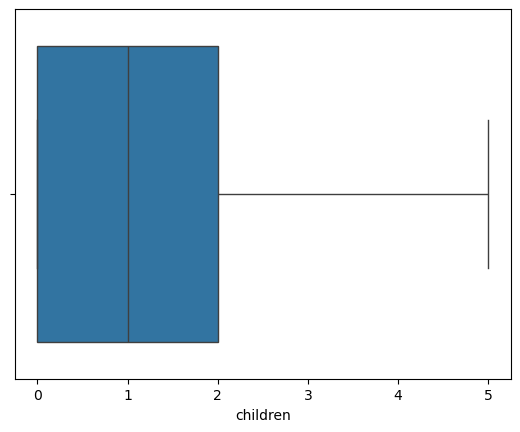

In [69]:
sns.boxplot(x=data_raw['children'])
plt.show()

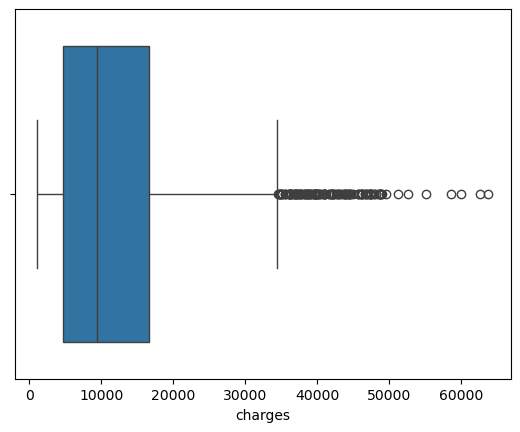

In [70]:
sns.boxplot(x=data_raw['charges'])
plt.show()

In [71]:
Q1 = data_raw["charges"].quantile(0.25)
Q3 = data_raw["charges"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_charges = data_raw[(data_raw["charges"] < limite_inferior) | (data_raw["charges"] > limite_superior)]

In [72]:
outliers_charges.sort_values(by="charges", ascending=False)

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
1300,45,male,30.360,0,yes,southeast,62592.87309
1230,52,male,34.485,3,yes,northwest,60021.39897
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209
...,...,...,...,...,...,...,...
1291,19,male,34.900,0,yes,southwest,34828.65400
689,27,male,31.130,1,yes,southeast,34806.46770
223,19,male,34.800,0,yes,southwest,34779.61500
1078,28,male,31.680,0,yes,southeast,34672.14720


Por el volumen de los datos y que si presentan valores de costos para la aseguradora, se opta por el metodo de Winsorizing, en lugar de simplemente eliminarlos, ya que presentan el 10% de los datos.

In [74]:
from scipy.stats.mstats import winsorize

data_raw['charges_winsorized'] = data_raw['charges'].clip(lower=limite_inferior, upper=limite_superior)

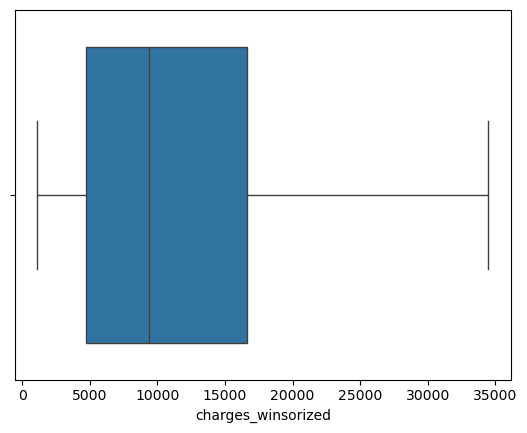

In [75]:
sns.boxplot(x=data_raw['charges_winsorized'])
plt.show()

In [80]:
data_clean = data_raw.copy()

data_clean.drop(columns=['charges'], inplace=True)

In [82]:
data_clean.rename(columns={'charges_winsorized': 'charges'}, inplace=True)

In [83]:
data_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Observar las distribuciones de las clases

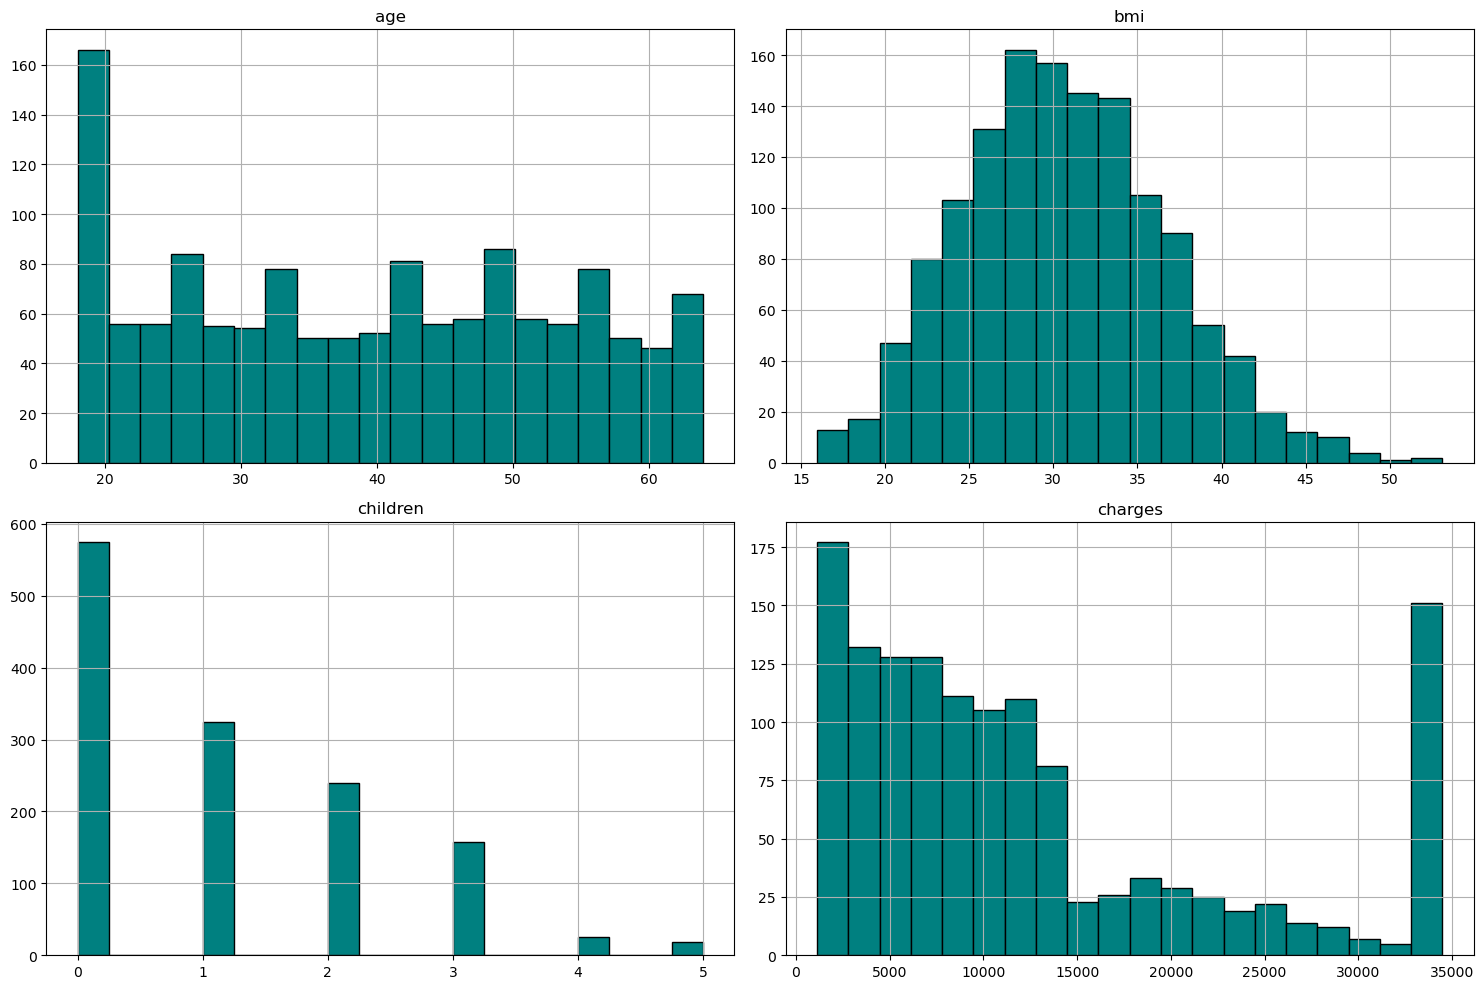

In [85]:
data_clean.hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.tight_layout()
plt.show()